**Visual Mood Recognition: A Multi-Classification**


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Dataset1 : https://www.kaggle.com/datasets/msambare/fer2013

Dataset2: https://www.kaggle.com/datasets/davilsena/ckdataset/data

Image Loading & PreProcessing

**->PreProcessing steps:**

Resize

Gray scale

Normalizing

Label Encoding

Split & Train Data

In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the directory containing the dataset
dataset_dir = '/content/drive/MyDrive/MV/MV_Data'

# Define the emotions (class labels)
emotions = ['disgust','happy','sad','surprise']

# Preprocessing function to read images, resize them, and normalize pixel values
def preprocess_image(file_path, target_size):
    #print(file_path)
    image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
    image = cv2.resize(image, target_size)  # Resize image
    image = image / 255.0  # Normalize pixel values
    return image

# Load images and labels
images = []
labels = []

for emotion_label, emotion in enumerate(emotions):
    emotion_dir = os.path.join(dataset_dir, emotion)
    for image_name in os.listdir(emotion_dir):
        image_path = os.path.join(emotion_dir, image_name)
        preprocessed_image = preprocess_image(image_path, (224, 224))  # Resize for ResNet50
        images.append(preprocessed_image)
        labels.append(emotion)

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Encode labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# Convert labels to one-hot encoded format
labels = to_categorical(labels, num_classes=len(emotions))

# Split data into training and testing sets
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)

ResNet50 Model

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input
import random
from sklearn.metrics import classification_report

94765736/94765736 [==============================] - 1s 0us/step
Epoch 1/10
12/12 [==============================] - 123s 9s/step - loss: 1.9218 - accuracy: 0.3472 - val_loss: 1.2529 - val_accuracy: 0.3750
Epoch 2/10
12/12 [==============================] - 83s 7s/step - loss: 1.3782 - accuracy: 0.4194 - val_loss: 1.1363 - val_accuracy: 0.4250
Epoch 3/10
12/12 [==============================] - 83s 7s/step - loss: 1.2602 - accuracy: 0.4167 - val_loss: 1.1210 - val_accuracy: 0.4250
Epoch 4/10
12/12 [==============================] - 82s 7s/step - loss: 1.2360 - accuracy: 0.3944 - val_loss: 1.1223 - val_accuracy: 0.4250
Epoch 5/10
12/12 [==============================] - 85s 7s/step - loss: 1.1954 - accuracy: 0.4333 - val_loss: 1.1085 - val_accuracy: 0.4250
Epoch 6/10
12/12 [==============================] - 85s 7s/step - loss: 1.2028 - accuracy: 0.4361 - val_loss: 1.1082 - val_accuracy: 0.4500
Epoch 7/10
12/12 [==============================] - 85s 7s/step - loss: 1.2104 - accuracy: 0.4

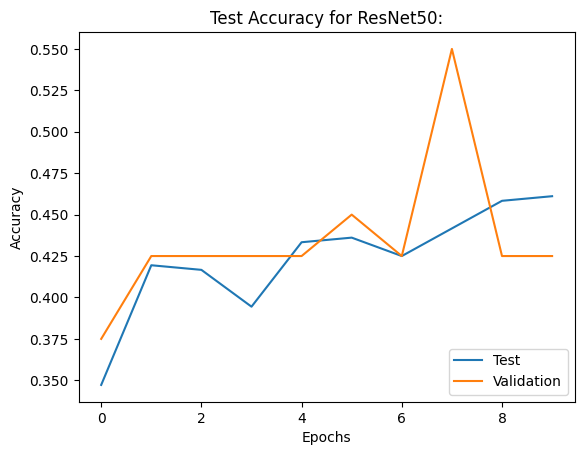

In [ ]:
# Reshape input images to have a shape of (batch_size, height, width, channels)
train_images_r = np.repeat(train_images[..., np.newaxis], 3, -1)
test_images_r = np.repeat(test_images[..., np.newaxis], 3, -1)

# Load pre-trained ResNet50 model (include_top=False for feature extraction)
resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the pre-trained ResNet50 model
for layer in resnet_model.layers:
    layer.trainable = False

# Create a new model with the ResNet50 base and additional layers for classification
model = Sequential([
    resnet_model,
    Flatten(),
    Dropout(0.5),  # Adding dropout for regularization
    Dense(128, activation='relu'),
    Dense(len(emotions), activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),  # Adjusted learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fit the model
history = model.fit(train_images_r, train_labels, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images_r, test_labels)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc * 100)

# Visualize training accuracy
plt.title("Test Accuracy for ResNet50:")
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Test', 'Validation'], loc='lower right')
plt.show()

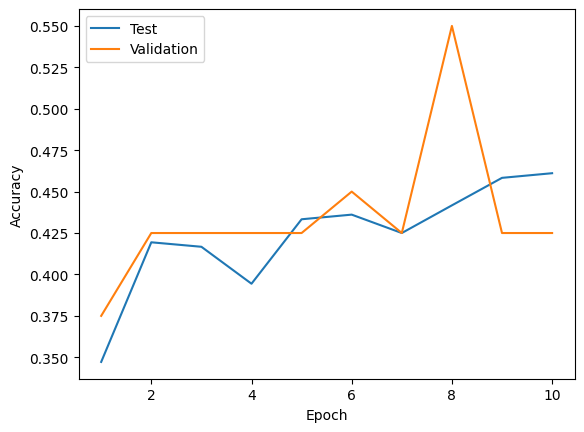

In [ ]:
import matplotlib.pyplot as plt

# Corrected Y1 list with proper commas
Y1 = [0.3472, 0.4194, 0.4167, 0.3944, 0.4333, 0.4361, 0.4250, 0.4417, 0.4583, 0.4611]
Y2 = [0.3750, 0.4250, 0.4250, 0.4250, 0.4250, 0.4500, 0.4250, 0.5500, 0.4250, 0.4250]
X = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

# Plotting the lines
plt.plot(X, Y1, label='Test')
plt.plot(X, Y2, label='Validation')

# Adding labels and title
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

# Adding a legend to differentiate between the two lines
plt.legend()

# Display the plot
plt.show()

4/4 [==============================] - 21s 5s/step
Report for ResNet50 model:
               precision    recall  f1-score   support

     disgust       1.00      0.08      0.15        37
       happy       0.35      1.00      0.52        34
         sad       0.00      0.00      0.00        19
    surprise       0.00      0.00      0.00        11

    accuracy                           0.37       101
   macro avg       0.34      0.27      0.17       101
weighted avg       0.48      0.37      0.23       101

Multi-Classification of mood through ResNet50 Model:



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


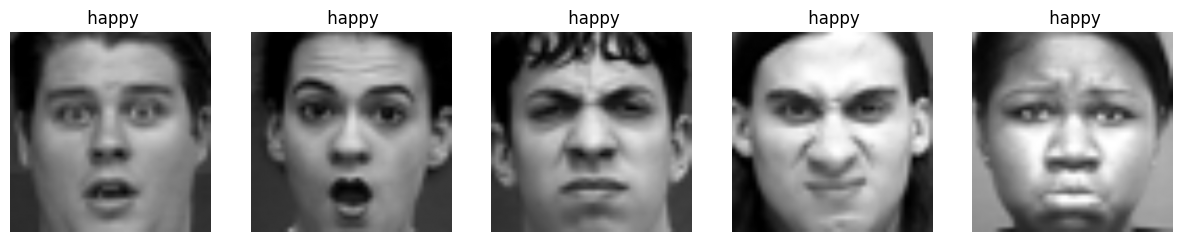

In [ ]:
predicted_labels = model.predict(test_images_r)
y_pred = [emotions[np.argmax(label)] for label in predicted_labels]
y_true = [emotions[np.argmax(label)] for label in test_labels]
# Compute classification report
report = classification_report(y_true, y_pred)

# Print classification report
print("Report for ResNet50 model:\n",report)
print("Multi-Classification of mood through ResNet50 Model:\n")
# Select random indices for sample images
sample_indices = random.sample(range(len(test_images_r)), 5)
#, cmap='Accent'
# Plot sample images
plt.figure(figsize=(15, 7))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images_r[idx])
    plt.title(f' {y_pred[idx]}')
    plt.axis('off')
plt.show()

VGG16 Model

58889256/58889256 [==============================] - 0s 0us/step
Epoch 1/10
12/12 [==============================] - 244s 20s/step - loss: 1.2081 - accuracy: 0.4500 - val_loss: 0.7092 - val_accuracy: 0.9000
Epoch 2/10
12/12 [==============================] - 264s 22s/step - loss: 0.7279 - accuracy: 0.7417 - val_loss: 0.4199 - val_accuracy: 0.8750
Epoch 3/10
12/12 [==============================] - 257s 22s/step - loss: 0.4685 - accuracy: 0.8556 - val_loss: 0.2341 - val_accuracy: 1.0000
Epoch 4/10
12/12 [==============================] - 246s 21s/step - loss: 0.2831 - accuracy: 0.9194 - val_loss: 0.1833 - val_accuracy: 0.9750
Epoch 5/10
12/12 [==============================] - 241s 20s/step - loss: 0.2054 - accuracy: 0.9528 - val_loss: 0.0925 - val_accuracy: 1.0000
Epoch 6/10
12/12 [==============================] - 258s 22s/step - loss: 0.1635 - accuracy: 0.9611 - val_loss: 0.0716 - val_accuracy: 1.0000
Epoch 7/10
12/12 [==============================] - 242s 20s/step - loss: 0.1198 - 

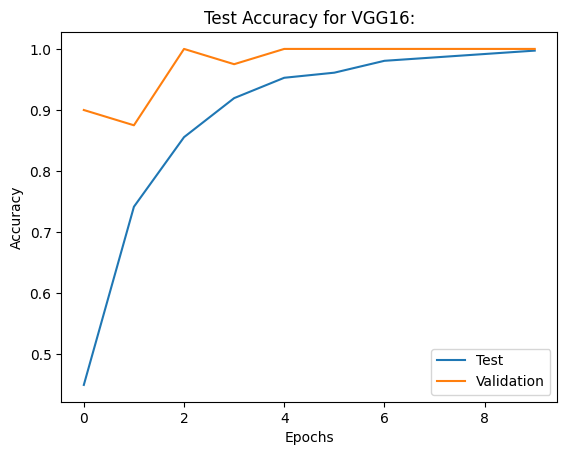

In [ ]:
train_images_vgg16 = train_images.reshape(train_images.shape[0], train_images.shape[1], train_images.shape[2], 1)
test_images_vgg16 = test_images.reshape(test_images.shape[0], test_images.shape[1], test_images.shape[2], 1)

# Convert grayscale images to RGB
train_images_vgg16_rgb = np.repeat(train_images_vgg16, 3, axis=-1)
test_images_vgg16_rgb = np.repeat(test_images_vgg16, 3, axis=-1)

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam

# Load pre-trained VGG16 model (include_top=False for feature extraction)
vgg16_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the pre-trained VGG16 model
for layer in vgg16_model.layers:
    layer.trainable = False

# Create a new model with the VGG16 base and additional layers for classification
model = Sequential([
    vgg16_model,
    Flatten(),
    Dropout(0.5),  # Adding dropout for regularization
    Dense(128, activation='relu'),
    Dense(len(emotions), activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),  # Adjusted learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history1=model.fit(train_images_vgg16_rgb, train_labels, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images_vgg16_rgb, test_labels)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc * 100)

# Visualize training accuracy
plt.title("Test Accuracy for VGG16:")
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Test', 'Validation'], loc='lower right')
plt.show()

4/4 [==============================] - 62s 14s/step
Report for VGG16 model:
               precision    recall  f1-score   support

     disgust       1.00      1.00      1.00        37
       happy       1.00      1.00      1.00        34
         sad       0.95      1.00      0.97        19
    surprise       1.00      0.91      0.95        11

    accuracy                           0.99       101
   macro avg       0.99      0.98      0.98       101
weighted avg       0.99      0.99      0.99       101

Multi-Classification of mood through VGG16 Model:



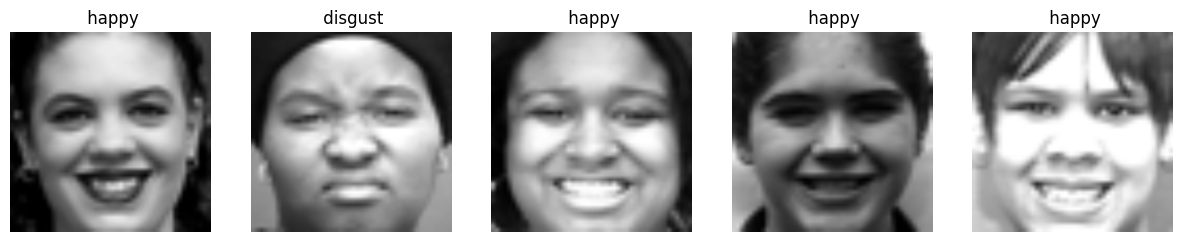

In [ ]:
predicted_labels1 = model.predict(test_images_vgg16_rgb)
y_pred1 = [emotions[np.argmax(label)] for label in predicted_labels1]
y_true = [emotions[np.argmax(label)] for label in test_labels]
# Compute classification report
report1 = classification_report(y_true, y_pred1)

# Print classification report
print("Report for VGG16 model:\n",report1)
print("Multi-Classification of mood through VGG16 Model:\n")
# Select random indices for sample images
sample_indices = random.sample(range(len(test_images_vgg16_rgb)), 5)
#, cmap='Accent'
# Plot sample images
plt.figure(figsize=(15, 7))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images_vgg16_rgb[idx])
    plt.title(f' {y_pred1[idx]}')
    plt.axis('off')
plt.show()

InceptionV3 Model

87910968/87910968 [==============================] - 1s 0us/step
Epoch 1/10
12/12 [==============================] - 107s 9s/step - loss: 2.0489 - accuracy: 0.5083 - val_loss: 0.4556 - val_accuracy: 0.8500
Epoch 2/10
12/12 [==============================] - 110s 9s/step - loss: 0.3573 - accuracy: 0.8889 - val_loss: 0.1469 - val_accuracy: 0.9750
Epoch 3/10
12/12 [==============================] - 100s 8s/step - loss: 0.1077 - accuracy: 0.9778 - val_loss: 0.0575 - val_accuracy: 0.9750
Epoch 4/10
12/12 [==============================] - 99s 8s/step - loss: 0.0309 - accuracy: 0.9944 - val_loss: 0.0116 - val_accuracy: 1.0000
Epoch 5/10
12/12 [==============================] - 112s 9s/step - loss: 0.0118 - accuracy: 1.0000 - val_loss: 0.0076 - val_accuracy: 1.0000
Epoch 6/10
12/12 [==============================] - 105s 9s/step - loss: 0.0061 - accuracy: 1.0000 - val_loss: 0.0054 - val_accuracy: 1.0000
Epoch 7/10
12/12 [==============================] - 100s 8s/step - loss: 0.0054 - accuracy

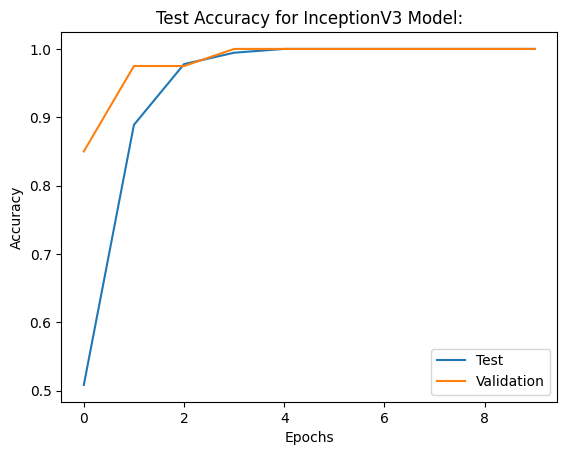

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

# Convert grayscale images to RGB format
train_images_rgb = np.repeat(train_images[..., np.newaxis], 3, -1)
test_images_rgb = np.repeat(test_images[..., np.newaxis], 3, -1)

# Resize the input images to match the expected input shape of the InceptionV3 model (299x299)
train_images_resized = np.array([cv2.resize(img, (299, 299)) for img in train_images_rgb])
test_images_resized = np.array([cv2.resize(img, (299, 299)) for img in test_images_rgb])

# Assuming 'emotions' is the number of classes in your classification task
num_classes = len(emotions)

# Load pre-trained InceptionV3 model (include_top=False for feature extraction)
inception_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

# Freeze the layers of the pre-trained InceptionV3 model
for layer in inception_model.layers:
    layer.trainable = False

# Create a new model with the InceptionV3 base and additional layers for classification
model = Sequential([
    inception_model,
    Flatten(),
    Dropout(0.5),  # Adding dropout for regularization
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),  # Adjusted learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history2=model.fit(train_images_resized, train_labels, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images_resized, test_labels)
print('Test accuracy:', test_acc * 100)

# Visualize training accuracy
plt.title("Test Accuracy for InceptionV3 Model:")
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Test', 'Validation'], loc='lower right')
plt.show()

4/4 [==============================] - 27s 6s/step
Report for InceptionV3 model:
               precision    recall  f1-score   support

     disgust       1.00      1.00      1.00        37
       happy       1.00      1.00      1.00        34
         sad       0.95      1.00      0.97        19
    surprise       1.00      0.91      0.95        11

    accuracy                           0.99       101
   macro avg       0.99      0.98      0.98       101
weighted avg       0.99      0.99      0.99       101

Multi-Classification of mood through InceptionV3 Model:



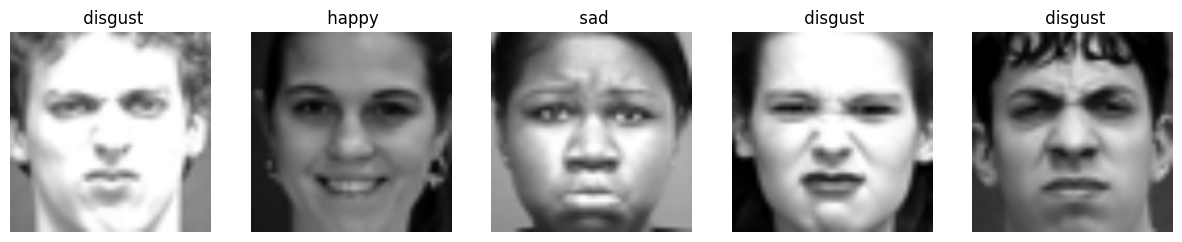

In [ ]:
predicted_labels2 = model.predict(test_images_resized)
y_pred2 = [emotions[np.argmax(label)] for label in predicted_labels2]
y_true = [emotions[np.argmax(label)] for label in test_labels]
# Compute classification report
report2 = classification_report(y_true, y_pred1)

# Print classification report
print("Report for InceptionV3 model:\n",report2)
print("Multi-Classification of mood through InceptionV3 Model:\n")
# Select random indices for sample images
sample_indices = random.sample(range(len(test_images_resized)), 5)
#, cmap='Accent'
# Plot sample images
plt.figure(figsize=(15, 7))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images_resized[idx])
    plt.title(f' {y_pred2[idx]}')
    plt.axis('off')
plt.show()

MobileNetV2

9406464/9406464 [==============================] - 0s 0us/step
Epoch 1/10
12/12 [==============================] - 29s 2s/step - loss: 2.0399 - accuracy: 0.5222 - val_loss: 0.4699 - val_accuracy: 0.8250
Epoch 2/10
12/12 [==============================] - 20s 2s/step - loss: 0.3595 - accuracy: 0.8778 - val_loss: 0.1463 - val_accuracy: 0.9500
Epoch 3/10
12/12 [==============================] - 18s 2s/step - loss: 0.1210 - accuracy: 0.9667 - val_loss: 0.0811 - val_accuracy: 0.9750
Epoch 4/10
12/12 [==============================] - 18s 2s/step - loss: 0.0327 - accuracy: 0.9917 - val_loss: 0.0166 - val_accuracy: 1.0000
Epoch 5/10
12/12 [==============================] - 20s 2s/step - loss: 0.0133 - accuracy: 0.9972 - val_loss: 0.0105 - val_accuracy: 1.0000
Epoch 6/10
12/12 [==============================] - 18s 2s/step - loss: 0.0070 - accuracy: 1.0000 - val_loss: 0.0065 - val_accuracy: 1.0000
Epoch 7/10
12/12 [==============================] - 19s 2s/step - loss: 0.0051 - accuracy: 1.0000

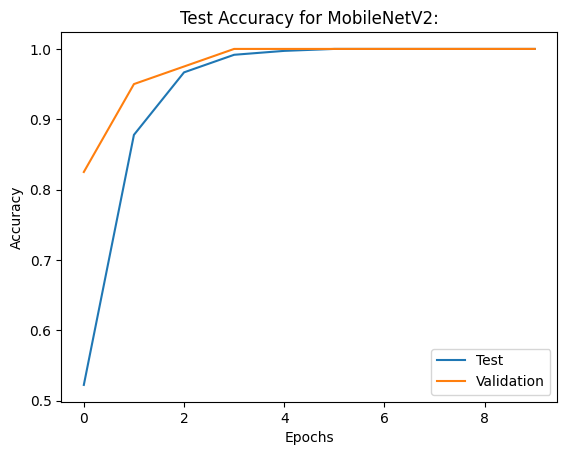

In [ ]:
from tensorflow.keras.applications import MobileNetV2
# Assuming 'emotions' is the number of classes in your classification task
num_classes = len(emotions)
train_images_mn = train_images.reshape(train_images.shape[0], train_images.shape[1], train_images.shape[2], 1)
test_images_mn = test_images.reshape(test_images.shape[0], test_images.shape[1], test_images.shape[2], 1)

# Convert grayscale images to RGB
train_images_rgb = np.repeat(train_images_mn, 3, axis=-1)
test_images_rgb = np.repeat(test_images_mn, 3, axis=-1)

# Load pre-trained MobileNetV2 model (include_top=False for feature extraction)
mobilenet_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the pre-trained MobileNetV2 model
for layer in mobilenet_model.layers:
    layer.trainable = False

# Create a new model with the MobileNetV2 base and additional layers for classification
model = Sequential([
    mobilenet_model,
    Flatten(),
    Dropout(0.5),  # Adding dropout for regularization
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),  # Adjusted learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history3=model.fit(train_images_rgb, train_labels, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images_rgb, test_labels)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc * 100)

# Visualize training accuracy
plt.title("Test Accuracy for MobileNetV2:")
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Test', 'Validation'], loc='lower right')
plt.show()

4/4 [==============================] - 5s 859ms/step
Report for MobileNetV2 model:
               precision    recall  f1-score   support

     disgust       1.00      0.97      0.99        37
       happy       1.00      1.00      1.00        34
         sad       0.95      1.00      0.97        19
    surprise       1.00      1.00      1.00        11

    accuracy                           0.99       101
   macro avg       0.99      0.99      0.99       101
weighted avg       0.99      0.99      0.99       101

Multi-Classification of mood through MobileNetV2 Model:



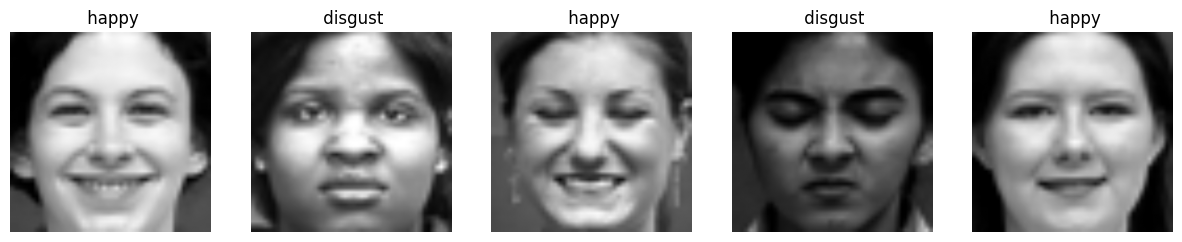

In [ ]:
predicted_labels3 = model.predict(test_images_rgb)
y_pred3 = [emotions[np.argmax(label)] for label in predicted_labels3]
y_true = [emotions[np.argmax(label)] for label in test_labels]
# Compute classification report
report3 = classification_report(y_true, y_pred3)

# Print classification report
print("Report for MobileNetV2 model:\n",report3)
print("Multi-Classification of mood through MobileNetV2 Model:\n")
# Select random indices for sample images
sample_indices = random.sample(range(len(test_images_rgb)), 5)
#, cmap='Accent'
# Plot sample images
plt.figure(figsize=(15, 7))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images_rgb[idx])
    plt.title(f' {y_pred3[idx]}')
    plt.axis('off')
plt.show()

DenseNet121 Model

29084464/29084464 [==============================] - 0s 0us/step
Epoch 1/10
12/12 [==============================] - 83s 6s/step - loss: 1.8159 - accuracy: 0.5528 - val_loss: 0.3433 - val_accuracy: 0.8750
Epoch 2/10
12/12 [==============================] - 73s 6s/step - loss: 0.4899 - accuracy: 0.8444 - val_loss: 0.2239 - val_accuracy: 0.9750
Epoch 3/10
12/12 [==============================] - 73s 6s/step - loss: 0.2376 - accuracy: 0.9222 - val_loss: 0.0345 - val_accuracy: 1.0000
Epoch 4/10
12/12 [==============================] - 71s 6s/step - loss: 0.1550 - accuracy: 0.9500 - val_loss: 0.0298 - val_accuracy: 1.0000
Epoch 5/10
12/12 [==============================] - 74s 6s/step - loss: 0.0596 - accuracy: 0.9833 - val_loss: 0.0092 - val_accuracy: 1.0000
Epoch 6/10
12/12 [==============================] - 73s 6s/step - loss: 0.0569 - accuracy: 0.9750 - val_loss: 0.0205 - val_accuracy: 1.0000
Epoch 7/10
12/12 [==============================] - 71s 6s/step - loss: 0.0376 - accuracy: 0.99

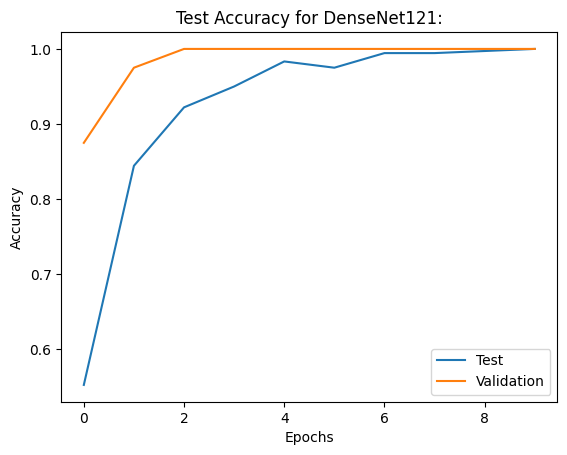

In [ ]:
from tensorflow.keras.applications import DenseNet121

# Assuming 'emotions' is the number of classes in your classification task
num_classes = len(emotions)

# Load pre-trained DenseNet model (include_top=False for feature extraction)
densenet_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the pre-trained DenseNet model
for layer in densenet_model.layers:
    layer.trainable = False

# Create a new model with the DenseNet base and additional layers for classification
model = Sequential([
    densenet_model,
    Flatten(),
    Dropout(0.5),  # Adding dropout for regularization
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),  # Adjusted learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history4=model.fit(train_images_rgb, train_labels, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images_rgb, test_labels)
print('Test accuracy:', test_acc * 100)

# Visualize training accuracy
plt.title("Test Accuracy for DenseNet121:")
plt.plot(history4.history['accuracy'])
plt.plot(history4.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Test', 'Validation'], loc='lower right')
plt.show()

4/4 [==============================] - 20s 4s/step
Report for DenseNet121 model:
               precision    recall  f1-score   support

     disgust       1.00      1.00      1.00        37
       happy       0.92      1.00      0.96        34
         sad       1.00      0.84      0.91        19
    surprise       1.00      1.00      1.00        11

    accuracy                           0.97       101
   macro avg       0.98      0.96      0.97       101
weighted avg       0.97      0.97      0.97       101

Multi-Classification of mood through DenseNet121 Model:



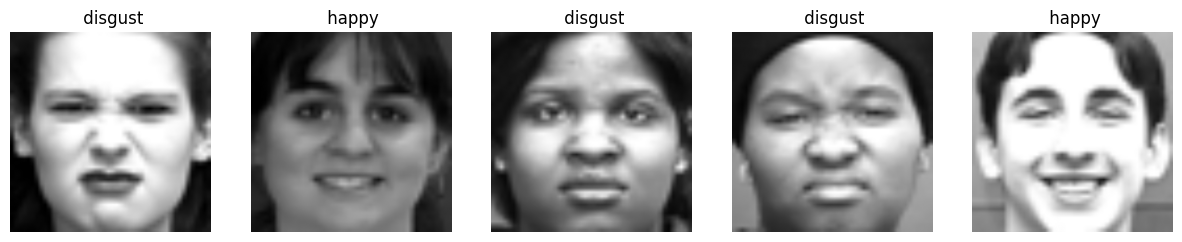

In [ ]:
predicted_labels4 = model.predict(test_images_rgb)
y_pred4 = [emotions[np.argmax(label)] for label in predicted_labels4]
y_true = [emotions[np.argmax(label)] for label in test_labels]
# Compute classification report
report4 = classification_report(y_true, y_pred4)

# Print classification report
print("Report for DenseNet121 model:\n",report4)
print("Multi-Classification of mood through DenseNet121 Model:\n")
# Select random indices for sample images
sample_indices = random.sample(range(len(test_images_rgb)), 5)
#, cmap='Accent'
# Plot sample images
plt.figure(figsize=(15, 7))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images_rgb[idx])
    plt.title(f' {y_pred4[idx]}')
    plt.axis('off')
plt.show()

Performance of Models

In [ ]:
print("For ResNet50 model:\n",report)
print("For VGG16 model:\n",report1)
print("For Inception3 model:\n",report2)
print("For MobileNetV2 model:\n",report3)
print("For Densenet121 model\n:",report4)

For ResNet50 model:
               precision    recall  f1-score   support

     disgust       1.00      0.08      0.15        37
       happy       0.35      1.00      0.52        34
         sad       0.00      0.00      0.00        19
    surprise       0.00      0.00      0.00        11

    accuracy                           0.37       101
   macro avg       0.34      0.27      0.17       101
weighted avg       0.48      0.37      0.23       101

For VGG16 model:
               precision    recall  f1-score   support

     disgust       1.00      1.00      1.00        37
       happy       1.00      1.00      1.00        34
         sad       0.95      1.00      0.97        19
    surprise       1.00      0.91      0.95        11

    accuracy                           0.99       101
   macro avg       0.99      0.98      0.98       101
weighted avg       0.99      0.99      0.99       101

For Inception3 model:
               precision    recall  f1-score   support

     disgust 

Slection of Model

In [ ]:
print("The Best Result from above model evaluation :")
print("MobileNetV2",report3)


The Best Result from above model evaluation :
MobileNetV2               precision    recall  f1-score   support

     disgust       1.00      0.97      0.99        37
       happy       1.00      1.00      1.00        34
         sad       0.95      1.00      0.97        19
    surprise       1.00      1.00      1.00        11

    accuracy                           0.99       101
   macro avg       0.99      0.99      0.99       101
weighted avg       0.99      0.99      0.99       101



For Dataset1

In [ ]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Define the directory containing the dataset
dataset_dir = '/content/drive/MyDrive/MV/Img_Dataset'

# Define the emotions (class labels)
emotions = ['disgust','happy','sad','surprise']

# Preprocessing function to read images, resize them, and normalize pixel values
def preprocess_image(file_path, target_size):
    #print(file_path)
    image = cv2.imread(file_path, cv2.IMREAD_GRAYSCALE)  # Convert to grayscale
    image = cv2.resize(image, target_size)  # Resize image
    image = image / 255.0  # Normalize pixel values
    return image

# Load images and labels
images = []
labels = []

for emotion_label, emotion in enumerate(emotions):
    emotion_dir = os.path.join(dataset_dir, emotion)
    for image_name in os.listdir(emotion_dir):
        image_path = os.path.join(emotion_dir, image_name)
        preprocessed_image = preprocess_image(image_path, (224, 224))  # Resize for ResNet50
        images.append(preprocessed_image)
        labels.append(emotion)

# Convert lists to numpy arrays
images = np.array(images)
labels = np.array(labels)

# Encode labels
label_encoder = LabelEncoder()
labels = label_encoder.fit_transform(labels)

# Convert labels to one-hot encoded format
labels = to_categorical(labels, num_classes=len(emotions))

# Split data into training and testing sets
train_images, test_images, train_labels, test_labels = train_test_split(images, labels, test_size=0.2, random_state=42)

ResNet50 Model

In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input
import random
from sklearn.metrics import classification_report

94765736/94765736 [==============================] - 1s 0us/step
Epoch 1/10
9/9 [==============================] - 100s 10s/step - loss: 2.2333 - accuracy: 0.2812 - val_loss: 1.3979 - val_accuracy: 0.2812
Epoch 2/10
9/9 [==============================] - 68s 7s/step - loss: 1.6180 - accuracy: 0.2674 - val_loss: 1.5256 - val_accuracy: 0.2812
Epoch 3/10
9/9 [==============================] - 65s 7s/step - loss: 1.5964 - accuracy: 0.2778 - val_loss: 1.5471 - val_accuracy: 0.2812
Epoch 4/10
9/9 [==============================] - 63s 7s/step - loss: 1.5235 - accuracy: 0.2604 - val_loss: 1.4638 - val_accuracy: 0.2812
Epoch 5/10
9/9 [==============================] - 64s 7s/step - loss: 1.4855 - accuracy: 0.2118 - val_loss: 1.3891 - val_accuracy: 0.2812
Epoch 6/10
9/9 [==============================] - 62s 7s/step - loss: 1.4180 - accuracy: 0.3160 - val_loss: 1.4016 - val_accuracy: 0.2188
Epoch 7/10
9/9 [==============================] - 58s 7s/step - loss: 1.4216 - accuracy: 0.2292 - val_los

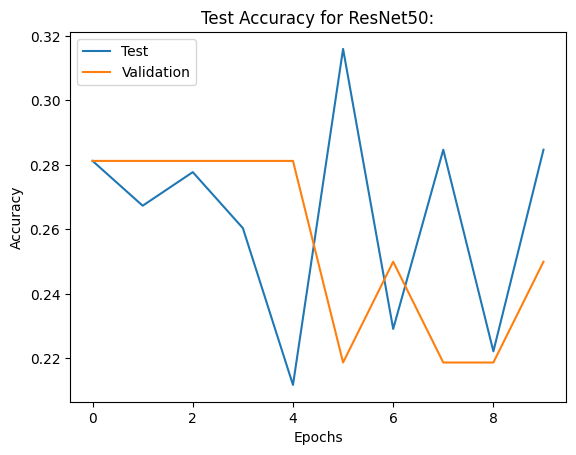

In [ ]:
# Reshape input images to have a shape of (batch_size, height, width, channels)
train_images_r = np.repeat(train_images[..., np.newaxis], 3, -1)
test_images_r = np.repeat(test_images[..., np.newaxis], 3, -1)

# Load pre-trained ResNet50 model (include_top=False for feature extraction)
resnet_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the pre-trained ResNet50 model
for layer in resnet_model.layers:
    layer.trainable = False

# Create a new model with the ResNet50 base and additional layers for classification
model = Sequential([
    resnet_model,
    Flatten(),
    Dropout(0.5),  # Adding dropout for regularization
    Dense(128, activation='relu'),
    Dense(len(emotions), activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),  # Adjusted learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Fit the model
history = model.fit(train_images_r, train_labels, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images_r, test_labels)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc * 100)

# Visualize training accuracy
plt.title("Test Accuracy for ResNet50:")
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Test', 'Validation'], loc='lower right')
plt.show()

3/3 [==============================] - 21s 7s/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


Report for ResNet50 model:
               precision    recall  f1-score   support

     disgust       0.00      0.00      0.00        26
       happy       0.27      0.89      0.41        18
         sad       0.00      0.00      0.00        18
    surprise       0.30      0.33      0.32        18

    accuracy                           0.28        80
   macro avg       0.14      0.31      0.18        80
weighted avg       0.13      0.28      0.16        80

Multi-Classification of mood through ResNet50 Model:



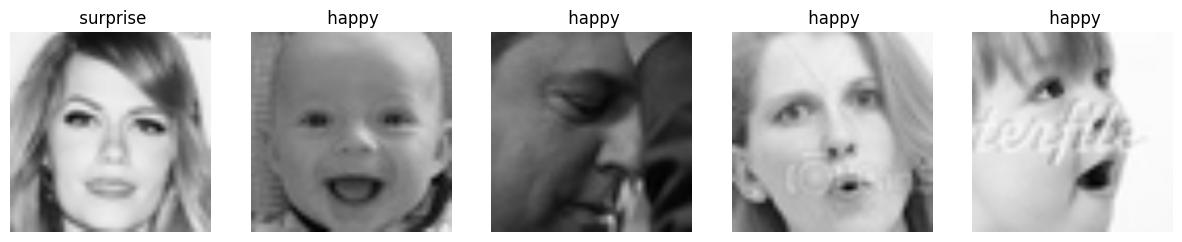

In [ ]:
predicted_labels = model.predict(test_images_r)
y_pred = [emotions[np.argmax(label)] for label in predicted_labels]
y_true = [emotions[np.argmax(label)] for label in test_labels]
# Compute classification report
report = classification_report(y_true, y_pred)

# Print classification report
print("Report for ResNet50 model:\n",report)
print("Multi-Classification of mood through ResNet50 Model:\n")
# Select random indices for sample images
sample_indices = random.sample(range(len(test_images_r)), 5)
#, cmap='Accent'
# Plot sample images
plt.figure(figsize=(15, 7))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images_r[idx])
    plt.title(f' {y_pred[idx]}')
    plt.axis('off')
plt.show()

VGG16 Model

Epoch 1/10
9/9 [==============================] - 199s 22s/step - loss: 1.6195 - accuracy: 0.2639 - val_loss: 1.2842 - val_accuracy: 0.3750
Epoch 2/10
9/9 [==============================] - 198s 22s/step - loss: 1.3667 - accuracy: 0.3819 - val_loss: 1.2555 - val_accuracy: 0.4688
Epoch 3/10
9/9 [==============================] - 196s 22s/step - loss: 1.2320 - accuracy: 0.4444 - val_loss: 1.2020 - val_accuracy: 0.3438
Epoch 4/10
9/9 [==============================] - 198s 22s/step - loss: 1.1301 - accuracy: 0.4896 - val_loss: 1.0941 - val_accuracy: 0.5938
Epoch 5/10
9/9 [==============================] - 197s 22s/step - loss: 1.0027 - accuracy: 0.5868 - val_loss: 0.9790 - val_accuracy: 0.6250
Epoch 6/10
9/9 [==============================] - 197s 22s/step - loss: 0.9144 - accuracy: 0.6354 - val_loss: 0.8897 - val_accuracy: 0.7188
Epoch 7/10
9/9 [==============================] - 197s 22s/step - loss: 0.8287 - accuracy: 0.6285 - val_loss: 0.8471 - val_accuracy: 0.7188
Epoch 8/10
9/9 [====

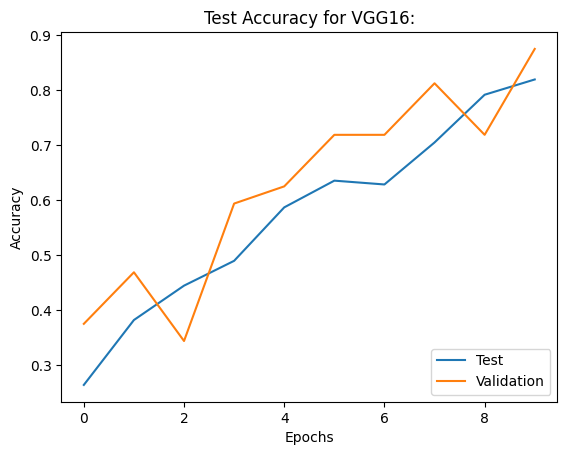

In [ ]:
train_images_vgg16 = train_images.reshape(train_images.shape[0], train_images.shape[1], train_images.shape[2], 1)
test_images_vgg16 = test_images.reshape(test_images.shape[0], test_images.shape[1], test_images.shape[2], 1)

# Convert grayscale images to RGB
train_images_vgg16_rgb = np.repeat(train_images_vgg16, 3, axis=-1)
test_images_vgg16_rgb = np.repeat(test_images_vgg16, 3, axis=-1)

from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dropout, Dense
from tensorflow.keras.optimizers import Adam

# Load pre-trained VGG16 model (include_top=False for feature extraction)
vgg16_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the pre-trained VGG16 model
for layer in vgg16_model.layers:
    layer.trainable = False

# Create a new model with the VGG16 base and additional layers for classification
model = Sequential([
    vgg16_model,
    Flatten(),
    Dropout(0.5),  # Adding dropout for regularization
    Dense(128, activation='relu'),
    Dense(len(emotions), activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),  # Adjusted learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history1=model.fit(train_images_vgg16_rgb, train_labels, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images_vgg16_rgb, test_labels)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc * 100)

# Visualize training accuracy
plt.title("Test Accuracy for VGG16:")
plt.plot(history1.history['accuracy'])
plt.plot(history1.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Test', 'Validation'], loc='lower right')
plt.show()

3/3 [==============================] - 48s 14s/step
Report for VGG16 model:
               precision    recall  f1-score   support

     disgust       0.79      0.73      0.76        26
       happy       0.40      0.56      0.47        18
         sad       0.41      0.39      0.40        18
    surprise       0.71      0.56      0.63        18

    accuracy                           0.57        80
   macro avg       0.58      0.56      0.56        80
weighted avg       0.60      0.57      0.58        80

Multi-Classification of mood through VGG16 Model:



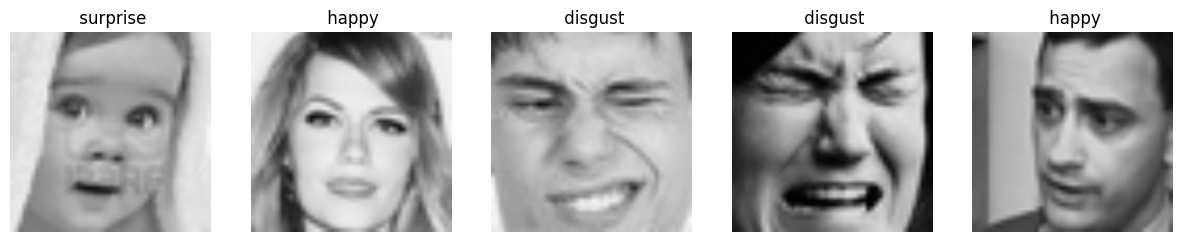

In [ ]:
predicted_labels1 = model.predict(test_images_vgg16_rgb)
y_pred1 = [emotions[np.argmax(label)] for label in predicted_labels1]
y_true = [emotions[np.argmax(label)] for label in test_labels]
# Compute classification report
report1 = classification_report(y_true, y_pred1)

# Print classification report
print("Report for VGG16 model:\n",report1)
print("Multi-Classification of mood through VGG16 Model:\n")
# Select random indices for sample images
sample_indices = random.sample(range(len(test_images_vgg16_rgb)), 5)
#, cmap='Accent'
# Plot sample images
plt.figure(figsize=(15, 7))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images_vgg16_rgb[idx])
    plt.title(f' {y_pred1[idx]}')
    plt.axis('off')
plt.show()

InceptionV3 Model

87910968/87910968 [==============================] - 1s 0us/step
Epoch 1/10
9/9 [==============================] - 82s 8s/step - loss: 2.6706 - accuracy: 0.3438 - val_loss: 1.4856 - val_accuracy: 0.5625
Epoch 2/10
9/9 [==============================] - 74s 8s/step - loss: 0.9234 - accuracy: 0.6389 - val_loss: 1.1154 - val_accuracy: 0.6250
Epoch 3/10
9/9 [==============================] - 72s 8s/step - loss: 0.5630 - accuracy: 0.7882 - val_loss: 1.0188 - val_accuracy: 0.6562
Epoch 4/10
9/9 [==============================] - 75s 9s/step - loss: 0.3320 - accuracy: 0.8889 - val_loss: 0.9596 - val_accuracy: 0.5938
Epoch 5/10
9/9 [==============================] - 75s 9s/step - loss: 0.1871 - accuracy: 0.9618 - val_loss: 1.0975 - val_accuracy: 0.5938
Epoch 6/10
9/9 [==============================] - 75s 9s/step - loss: 0.0991 - accuracy: 0.9896 - val_loss: 1.0295 - val_accuracy: 0.7188
Epoch 7/10
9/9 [==============================] - 74s 8s/step - loss: 0.0680 - accuracy: 0.9965 - val_loss:

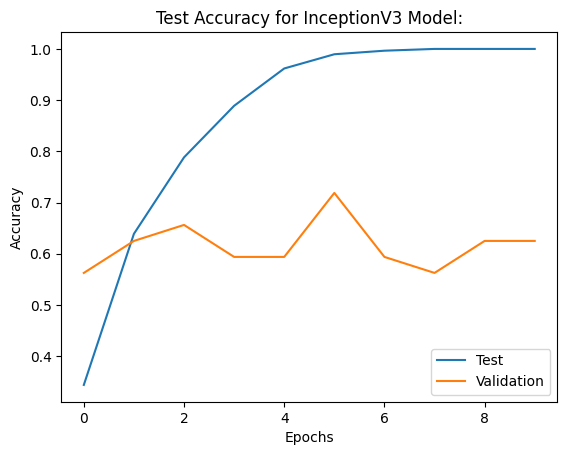

In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.applications.inception_v3 import preprocess_input
from tensorflow.keras.preprocessing.image import img_to_array

# Convert grayscale images to RGB format
train_images_rgb = np.repeat(train_images[..., np.newaxis], 3, -1)
test_images_rgb = np.repeat(test_images[..., np.newaxis], 3, -1)

# Resize the input images to match the expected input shape of the InceptionV3 model (299x299)
train_images_resized = np.array([cv2.resize(img, (299, 299)) for img in train_images_rgb])
test_images_resized = np.array([cv2.resize(img, (299, 299)) for img in test_images_rgb])

# Assuming 'emotions' is the number of classes in your classification task
num_classes = len(emotions)

# Load pre-trained InceptionV3 model (include_top=False for feature extraction)
inception_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))

# Freeze the layers of the pre-trained InceptionV3 model
for layer in inception_model.layers:
    layer.trainable = False

# Create a new model with the InceptionV3 base and additional layers for classification
model = Sequential([
    inception_model,
    Flatten(),
    Dropout(0.5),  # Adding dropout for regularization
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),  # Adjusted learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history2=model.fit(train_images_resized, train_labels, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images_resized, test_labels)
print('Test accuracy:', test_acc * 100)

# Visualize training accuracy
plt.title("Test Accuracy for InceptionV3 Model:")
plt.plot(history2.history['accuracy'])
plt.plot(history2.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Test', 'Validation'], loc='lower right')
plt.show()

3/3 [==============================] - 19s 5s/step
Report for InceptionV3 model:
               precision    recall  f1-score   support

     disgust       0.77      0.77      0.77        26
       happy       0.50      0.39      0.44        18
         sad       0.45      0.28      0.34        18
    surprise       0.59      0.94      0.72        18

    accuracy                           0.61        80
   macro avg       0.58      0.60      0.57        80
weighted avg       0.60      0.61      0.59        80

Multi-Classification of mood through InceptionV3 Model:



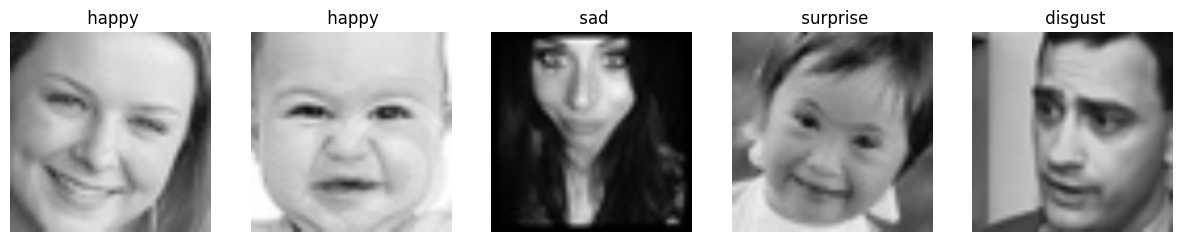

In [ ]:
predicted_labels2 = model.predict(test_images_resized)
y_pred2 = [emotions[np.argmax(label)] for label in predicted_labels2]
y_true = [emotions[np.argmax(label)] for label in test_labels]
# Compute classification report
report2 = classification_report(y_true, y_pred1)

# Print classification report
print("Report for InceptionV3 model:\n",report2)
print("Multi-Classification of mood through InceptionV3 Model:\n")
# Select random indices for sample images
sample_indices = random.sample(range(len(test_images_resized)), 5)
#, cmap='Accent'
# Plot sample images
plt.figure(figsize=(15, 7))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images_resized[idx])
    plt.title(f' {y_pred2[idx]}')
    plt.axis('off')
plt.show()

MobileNetV2 Model

9406464/9406464 [==============================] - 0s 0us/step
Epoch 1/10
9/9 [==============================] - 19s 2s/step - loss: 2.1696 - accuracy: 0.3854 - val_loss: 1.8014 - val_accuracy: 0.3750
Epoch 2/10
9/9 [==============================] - 12s 1s/step - loss: 1.1183 - accuracy: 0.5833 - val_loss: 0.7315 - val_accuracy: 0.6875
Epoch 3/10
9/9 [==============================] - 12s 1s/step - loss: 0.4552 - accuracy: 0.8264 - val_loss: 0.7064 - val_accuracy: 0.7500
Epoch 4/10
9/9 [==============================] - 12s 1s/step - loss: 0.2574 - accuracy: 0.9097 - val_loss: 0.7358 - val_accuracy: 0.5938
Epoch 5/10
9/9 [==============================] - 12s 1s/step - loss: 0.1179 - accuracy: 0.9688 - val_loss: 0.6853 - val_accuracy: 0.6562
Epoch 6/10
9/9 [==============================] - 11s 1s/step - loss: 0.0569 - accuracy: 0.9931 - val_loss: 0.6217 - val_accuracy: 0.8125
Epoch 7/10
9/9 [==============================] - 13s 1s/step - loss: 0.0372 - accuracy: 0.9931 - val_loss: 0

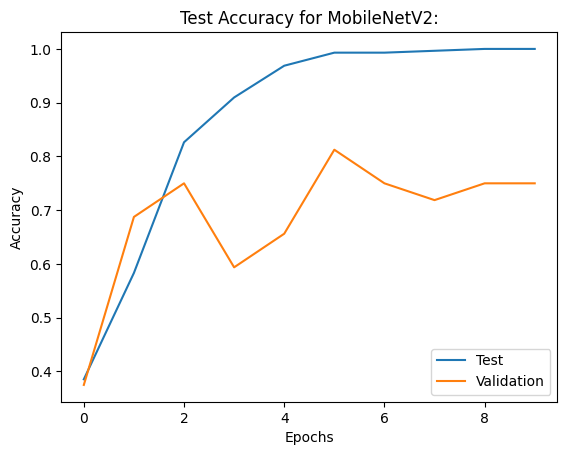

In [ ]:
from tensorflow.keras.applications import MobileNetV2
# Assuming 'emotions' is the number of classes in your classification task
num_classes = len(emotions)
train_images_mn = train_images.reshape(train_images.shape[0], train_images.shape[1], train_images.shape[2], 1)
test_images_mn = test_images.reshape(test_images.shape[0], test_images.shape[1], test_images.shape[2], 1)

# Convert grayscale images to RGB
train_images_rgb = np.repeat(train_images_mn, 3, axis=-1)
test_images_rgb = np.repeat(test_images_mn, 3, axis=-1)

# Load pre-trained MobileNetV2 model (include_top=False for feature extraction)
mobilenet_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the pre-trained MobileNetV2 model
for layer in mobilenet_model.layers:
    layer.trainable = False

# Create a new model with the MobileNetV2 base and additional layers for classification
model = Sequential([
    mobilenet_model,
    Flatten(),
    Dropout(0.5),  # Adding dropout for regularization
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),  # Adjusted learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history3=model.fit(train_images_rgb, train_labels, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images_rgb, test_labels)
print('Test loss:', test_loss)
print('Test accuracy:', test_acc * 100)

# Visualize training accuracy
plt.title("Test Accuracy for MobileNetV2:")
plt.plot(history3.history['accuracy'])
plt.plot(history3.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Test', 'Validation'], loc='lower right')
plt.show()

3/3 [==============================] - 4s 726ms/step
Report for MobileNetV2 model:
               precision    recall  f1-score   support

     disgust       0.71      0.65      0.68        26
       happy       0.27      0.17      0.21        18
         sad       0.26      0.39      0.31        18
    surprise       0.56      0.56      0.56        18

    accuracy                           0.46        80
   macro avg       0.45      0.44      0.44        80
weighted avg       0.47      0.46      0.46        80

Multi-Classification of mood through MobileNetV2 Model:



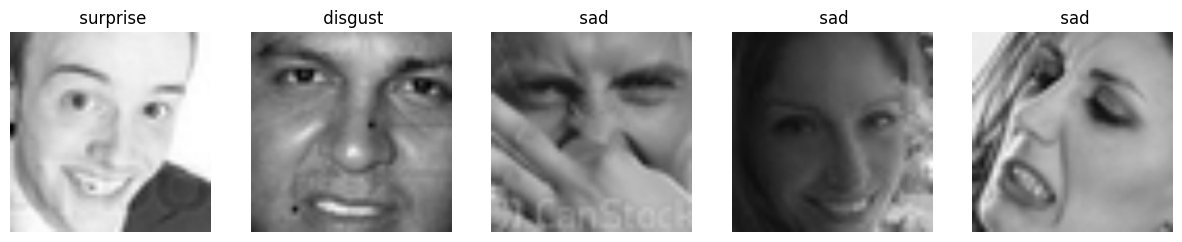

In [ ]:
predicted_labels3 = model.predict(test_images_rgb)
y_pred3 = [emotions[np.argmax(label)] for label in predicted_labels3]
y_true = [emotions[np.argmax(label)] for label in test_labels]
# Compute classification report
report3 = classification_report(y_true, y_pred3)

# Print classification report
print("Report for MobileNetV2 model:\n",report3)
print("Multi-Classification of mood through MobileNetV2 Model:\n")
# Select random indices for sample images
sample_indices = random.sample(range(len(test_images_rgb)), 5)
#, cmap='Accent'
# Plot sample images
plt.figure(figsize=(15, 7))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images_rgb[idx])
    plt.title(f' {y_pred3[idx]}')
    plt.axis('off')
plt.show()

DenseNet121

29084464/29084464 [==============================] - 0s 0us/step
Epoch 1/10
9/9 [==============================] - 62s 6s/step - loss: 2.0447 - accuracy: 0.2847 - val_loss: 1.0982 - val_accuracy: 0.5000
Epoch 2/10
9/9 [==============================] - 51s 6s/step - loss: 1.0164 - accuracy: 0.5799 - val_loss: 0.7897 - val_accuracy: 0.7188
Epoch 3/10
9/9 [==============================] - 50s 6s/step - loss: 0.6992 - accuracy: 0.7500 - val_loss: 0.7898 - val_accuracy: 0.6562
Epoch 4/10
9/9 [==============================] - 52s 6s/step - loss: 0.5037 - accuracy: 0.8194 - val_loss: 0.7732 - val_accuracy: 0.7188
Epoch 5/10
9/9 [==============================] - 52s 6s/step - loss: 0.3652 - accuracy: 0.8646 - val_loss: 0.7363 - val_accuracy: 0.7188
Epoch 6/10
9/9 [==============================] - 53s 6s/step - loss: 0.3218 - accuracy: 0.8715 - val_loss: 0.7496 - val_accuracy: 0.7500
Epoch 7/10
9/9 [==============================] - 52s 6s/step - loss: 0.2338 - accuracy: 0.9167 - val_loss:

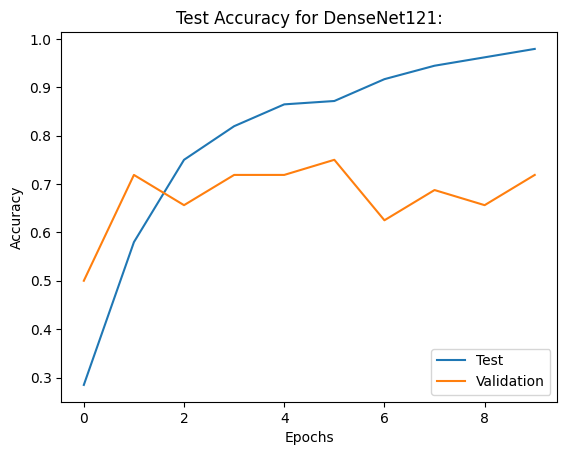

In [ ]:
from tensorflow.keras.applications import DenseNet121

# Assuming 'emotions' is the number of classes in your classification task
num_classes = len(emotions)

# Load pre-trained DenseNet model (include_top=False for feature extraction)
densenet_model = DenseNet121(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# Freeze the layers of the pre-trained DenseNet model
for layer in densenet_model.layers:
    layer.trainable = False

# Create a new model with the DenseNet base and additional layers for classification
model = Sequential([
    densenet_model,
    Flatten(),
    Dropout(0.5),  # Adding dropout for regularization
    Dense(128, activation='relu'),
    Dense(num_classes, activation='softmax')
])

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001),  # Adjusted learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history4=model.fit(train_images_rgb, train_labels, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images_rgb, test_labels)
print('Test accuracy:', test_acc * 100)

# Visualize training accuracy
plt.title("Test Accuracy for DenseNet121:")
plt.plot(history4.history['accuracy'])
plt.plot(history4.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Test', 'Validation'], loc='lower right')
plt.show()

3/3 [==============================] - 15s 4s/step
Report for DenseNet121 model:
               precision    recall  f1-score   support

     disgust       0.61      0.54      0.57        26
       happy       0.44      0.39      0.41        18
         sad       0.53      0.50      0.51        18
    surprise       0.62      0.83      0.71        18

    accuracy                           0.56        80
   macro avg       0.55      0.57      0.55        80
weighted avg       0.56      0.56      0.55        80

Multi-Classification of mood through DenseNet121 Model:



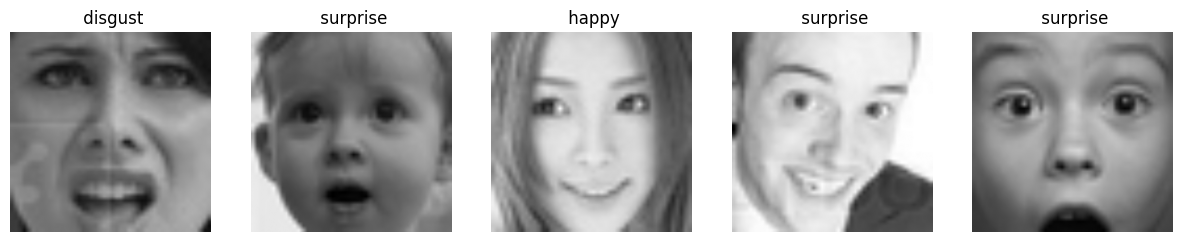

In [ ]:
predicted_labels4 = model.predict(test_images_rgb)
y_pred4 = [emotions[np.argmax(label)] for label in predicted_labels4]
y_true = [emotions[np.argmax(label)] for label in test_labels]
# Compute classification report
report4 = classification_report(y_true, y_pred4)

# Print classification report
print("Report for DenseNet121 model:\n",report4)
print("Multi-Classification of mood through DenseNet121 Model:\n")
# Select random indices for sample images
sample_indices = random.sample(range(len(test_images_rgb)), 5)
#, cmap='Accent'
# Plot sample images
plt.figure(figsize=(15, 7))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images_rgb[idx])
    plt.title(f' {y_pred4[idx]}')
    plt.axis('off')
plt.show()

In [ ]:
print("For ResNet50 model:\n",report)
print("For VGG16 model:\n",report1)
print("For Inception3 model:\n",report2)
print("For MobileNetV2 model:\n",report3)
print("For Densenet121 model\n:",report4)

For ResNet50 model:
               precision    recall  f1-score   support

     disgust       0.00      0.00      0.00        26
       happy       0.27      0.89      0.41        18
         sad       0.00      0.00      0.00        18
    surprise       0.30      0.33      0.32        18

    accuracy                           0.28        80
   macro avg       0.14      0.31      0.18        80
weighted avg       0.13      0.28      0.16        80

For VGG16 model:
               precision    recall  f1-score   support

     disgust       0.77      0.77      0.77        26
       happy       0.50      0.39      0.44        18
         sad       0.45      0.28      0.34        18
    surprise       0.59      0.94      0.72        18

    accuracy                           0.61        80
   macro avg       0.58      0.60      0.57        80
weighted avg       0.60      0.61      0.59        80

For Inception3 model:
               precision    recall  f1-score   support

     disgust 

Extra Sequential Model

In [ ]:
from tensorflow.keras.layers import Conv2D, MaxPooling2D

# Define the model architecture
model = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(len(emotions), activation='softmax')
])

# Compile the model
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

history5 = model.fit(train_images, train_labels, epochs=10, batch_size=32, validation_split=0.1)

# Evaluate the model
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test accuracy:', test_acc * 100)

# Visualize training accuracy
plt.title("Test Accuracy for Sequantial Model:")
plt.plot(history5.history['accuracy'])
plt.plot(history5.history['val_accuracy'])
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(['Test', 'Validation'], loc='lower right')
plt.show()

In [ ]:
predicted_labels5 = model.predict(test_images)
y_pred5 = [emotions[np.argmax(label)] for label in predicted_labels5]
y_true = [emotions[np.argmax(label)] for label in test_labels]
# Compute classification report
report5 = classification_report(y_true, y_pred5)

# Print classification report
print("Report for Sequential model:\n",report5)
print("Multi-Classification of mood through Sequential Model:\n")
# Select random indices for sample images
sample_indices = random.sample(range(len(test_images)), 5)
#, cmap='Accent'
# Plot sample images
plt.figure(figsize=(15, 7))
for i, idx in enumerate(sample_indices):
    plt.subplot(1, 5, i+1)
    plt.imshow(test_images[idx])
    plt.title(f' {y_pred5[idx]}')
    plt.axis('off')
plt.show()